## Setup

In [1]:
!pip install textacy
!pip install PyPDF2
!pip install sumy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.7/210.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.6/321.6 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 96.5 MB/s eta 0:00:00
  Created wheel for breadability: filename=breadability-0.1.20-py2.py3-none-any.whl size=21695 sha256=479abb8ad96859da491c4f4afe609cd9884d9ece9ca280fe0577d54b7c3a0030
  Stored in directory: /root/.cache/pip/wheels/32/99/64/59305409cacd03aa03e7bddf31a9db34b1fa7033bd41972662
  Created whe

In [2]:
# Libraries
import html
import re
import numpy as np
import pandas as pd
import textacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from spacy.lang.en.stop_words import STOP_WORDS as stopwords
from PyPDF2 import PdfReader
import matplotlib.pyplot as plt
import nltk

In [4]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = f"/content/drive/MyDrive/ft370_project/data/"

Mounted at /content/drive


In [5]:
# File Dictionary
filings_10k = {

    "TSLA": {
        2024: BASE_DIR + "TSLA2410K.pdf",
        2023: BASE_DIR + "TSLA2310K.pdf",
    },

    "RIVN": {
        2024: BASE_DIR + "RIVN2410K.pdf",
        2023: BASE_DIR + "RIVN2310K.pdf",
    },
}

earnings = {
    "TSLA": BASE_DIR + "TSLA_EARNINGS.pdf",
    "RIVN": BASE_DIR + "RIVN_EARNINGS.pdf"
}

## Extract Necessary Data

For each company we need the following data:
- 10k item 1A
- 10k item 7
- Entire Earning Transcript
- MD Section from Earnings Transcript
- Q&A Section from Earnings Transcript

In [6]:
def extract_item(file, first_page, last_page):
     # Start PDF Reader
    reader = PdfReader(file)

    # Initiate page count
    page_count = first_page

    # Initiate empty list
    pages = []

    # Loop through pages
    for _ in range(last_page - first_page + 1):
        # Read page
        page = reader.pages[page_count]
        # Extract page
        page_text = page.extract_text()
        # Append text to pages list
        pages.append(page_text)
        # Increase page_count
        page_count += 1

    # Join strings
    item = " ".join(pages)

    return item

In [7]:
# Finding first & last page (EXPLORATIVE)

# Start PDF Reader
reader = PdfReader(filings_10k['TSLA'][2023]) # CHANGE FILE HERE

#Find page
page = reader.pages[14] # CHANGE PAGE NUMBER HERE BASED ON PDF

# Extract page
page_text = page.extract_text()

# Display text
page_text

'Table of Contents\n•Engineering Development Program –\u2009Launched in January 2024, this program targets recent college and university graduates for specialized\nengineering fields. In collaboration with Austin Community College, the program educates early-career engineers in controls engineering,\nenhancing their knowledge of high-demand technologies for U.S. manufacturing.\nWe will continue to expand the opportunities for our employees to add skills and develop professionally with a new Employee Educational Assistance\nProgram launching in the U.S. in the spring of 2024 to help employees pursue select certificates or degrees. With virtual, self-paced education options\navailable, employees can pursue a new path or expand their knowledge while continuing to grow their career.\nAt Tesla, our employees show up passionate about making a difference in the world and for each other. We remain unwavering in our demand that our\nfactories, offices, stores and service centers are places wher

In [8]:
item7 = {
    "TSLA": {
            2024: extract_item(filings_10k['TSLA'][2024], 34, 46),
            2023: extract_item(filings_10k['TSLA'][2023], 33, 45)
        },
    "RIVN": {
            2024: extract_item(filings_10k['RIVN'][2024], 62, 75),
            2023: extract_item(filings_10k['RIVN'][2023], 56, 65)
        }
}

item1a = {

    "TSLA": {
        2024: extract_item(filings_10k['TSLA'][2024], 15, 29),
        2023: extract_item(filings_10k['TSLA'][2023], 14, 28)
    },

    "RIVN": {
        2024: extract_item(filings_10k['RIVN'][2024], 15, 56),
        2023: extract_item(filings_10k['RIVN'][2023], 14, 51)
    }
}

Prompt: how can I get a string of text, and only select whats in between "MANAGEMENT DISCUSSION SECTION" and "QUESTION AND ANSWER SECTION".

In [9]:
# Function to extract management discussion section
def extract_management_discussion(text):
    pattern = re.compile(
        r"MANAGEMENT DISCUSSION SECTION(.*?)QUESTION AND ANSWER SECTION",
        re.DOTALL | re.IGNORECASE
    )
    match = pattern.search(text)
    return match.group(1).strip() if match else None

# Function to extract Q&A discussion section
def extract_Q_and_A_discussion(text, last_sentence):
    pattern = re.compile(
        r"QUESTION AND ANSWER SECTION\s*(.*)(" + re.escape(last_sentence) + r")",
        re.DOTALL | re.IGNORECASE
    )
    match = pattern.search(text)
    return match.group(1).strip() + " " + last_sentence if match else None

In [10]:
# Rivian Earnings Call
# Initiate PDF Reader
reader = PdfReader(earnings['RIVN'])

# Function to disregard heading & footers
def visitor_body(text, cm, tm, fontDict, fontSize):
    y = tm[5]
    if y > 50 and y < 720:
        parts.append(text)

# Initiate empty list
parts = []

# Loop through pages
for _ in range(18):
    page = reader.pages[_ + 1]
    page.extract_text(visitor_text=visitor_body)

# Store transcript
rivn_earnings_transcript = "".join(parts)

In [11]:
# Tesla Earnings Call
# Initiate PDF Reader
reader = PdfReader(earnings['TSLA'])

# Initiate empty list
parts = []

# Loop through pages
for _ in range(20):
    page = reader.pages[_ + 1]
    page.extract_text(visitor_text=visitor_body)

# Store transcript
tsla_earnings_transcript = "".join(parts)

In [12]:
# Create earnings dataframe

earnings_data = {
    "tkr": ["TSLA", "RIVN"],
    "date": ["29-Jan-2025", "20-Feb-2025"],
    "text": [tsla_earnings_transcript,rivn_earnings_transcript]
}

df_earnings_call = pd.DataFrame(earnings_data)
df_earnings_call

,tkr,date,text
0,TSLA,29-Jan-2025,\nCORPORATE PARTICIPANTS \n \nTravis Axelro...
1,RIVN,20-Feb-2025,\nCORPORATE PARTICIPANTS \n \nTimothy Bei ...


In [13]:
# Extract rivn management section from earnings call
rivn_management_discussion = extract_management_discussion(df_earnings_call['text'].loc[1])

# Extract rivn Q&A section from earnings call
rivn_QA_discussion = extract_Q_and_A_discussion(df_earnings_call['text'].loc[1], "forward to the next one")

In [14]:
# Extract tsla management section from earnings call
tsla_management_discussion = extract_management_discussion(df_earnings_call['text'].loc[0])

# Extract tsla Q&A section from earnings call
tsla_QA_discussion = extract_Q_and_A_discussion(df_earnings_call['text'].loc[0], "Disclaimer")
# Remove "Disclaimer"
tsla_QA_discussion = tsla_QA_discussion.replace('Disclaimer', '')

Now that we have all the necessary data extracted, lets add it to a DataFrame

In [15]:
# Create earnings dataframe

earnings_data = {
    "tikr": ["TSLA", "RIVN"],
    "earnings call": [tsla_earnings_transcript, rivn_earnings_transcript],
    "management discussion": [tsla_management_discussion, rivn_management_discussion],
    "q&a": [tsla_QA_discussion, rivn_QA_discussion]
}

df_earnings = pd.DataFrame(earnings_data)
df_earnings

,tikr,earnings call,management discussion,q&a
0,TSLA,\nCORPORATE PARTICIPANTS \n \nTravis Axelro...,"Travis Axelrod \nHead -Investor Relations, Te...","Travis Axelrod \nHead -Investor Relations, Te..."
1,RIVN,\nCORPORATE PARTICIPANTS \n \nTimothy Bei ...,Operator : Good day. Thank you for standing by...,Operator : [Operator Instructions] Thank you. ...


In [16]:
# Create 10k dataframe

filings_10k_data = {
    "year": [2023, 2024, 2023, 2024],
    "tikr": ["TSLA", "TSLA", "RIVN", "RIVN"],
    "item1a": [item1a['TSLA'][2023], item1a['TSLA'][2024], item1a['RIVN'][2023], item1a['RIVN'][2024]],
    "item7": [item7['TSLA'][2023], item7['TSLA'][2024], item7['RIVN'][2023], item7['RIVN'][2024]]
}

df_10ks = pd.DataFrame(filings_10k_data)
df_10ks

,year,tikr,item1a,item7
0,2023,TSLA,Table of Contents\n•Engineering Development Pr...,ITEM 7. MANAGEMENT’S DISCUSSION AND ANALYSIS O...
1,2024,TSLA,"Table of Contents\nWith this in mind, we will ...",ITEM 7. MANAGEMENT’S DISCUSSION AND ANALYSIS O...
2,2023,RIVN,"RIVIAN A UTOMO TIVE, INC.\n501(c)(3) private f...","RIVIAN A UTOMO TIVE, INC.\nItem 7. Management’..."
3,2024,RIVN,"RIVIAN A UTOMO TIVE, INC.\nItem 1A. Risk Facto...","RIVIAN A UTOMO TIVE, INC.\nItem 7. Management’..."


## Cleaning Data

To-do:
- clean df_earnings_call
- clean df_10ks

### clean df_earnings_call

In [17]:
def clean(text):
    # convert html escapes like &amp; to characters.
    text = html.unescape(text)
    # tags like <tab>
    text = re.sub(r'<[^<>]*>', ' ', text)
    # markdown URLs like [Some text](https://....)
    # performs a substitution on text, replacing markdown-style links [Some text](URL) with just text (removing the URL and the surrounding Markdown syntax)
    text = re.sub(r'\[([^\[\]]*)\]\([^\(\)]*\)', r'\1', text)
    # text or code in brackets like [0]
    text = re.sub(r'\[[^\[\]]*\]', ' ', text)
    # standalone sequences of specials, matches &# but not #cool
    text = re.sub(r'(?:^|\s)[&#<>{}\[\]+|\\:-]{1,}(?:\s|$)', ' ', text)
    # standalone sequences of hyphens like --- or ==
    text = re.sub(r'(?:^|\s)[\-=\+]{2,}(?:\s|$)', ' ', text)
    # sequences of white spaces
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [18]:
df_earnings

,tikr,earnings call,management discussion,q&a
0,TSLA,\nCORPORATE PARTICIPANTS \n \nTravis Axelro...,"Travis Axelrod \nHead -Investor Relations, Te...","Travis Axelrod \nHead -Investor Relations, Te..."
1,RIVN,\nCORPORATE PARTICIPANTS \n \nTimothy Bei ...,Operator : Good day. Thank you for standing by...,Operator : [Operator Instructions] Thank you. ...


In [19]:
# Apply clean function df_earnings['text']
df_earnings['earnings_call_clean_text'] = df_earnings['earnings call'].map(clean)
df_earnings['management_discussion_clean_text'] = df_earnings['management discussion'].map(clean)
df_earnings['q&a_clean_text'] = df_earnings['q&a'].map(clean)

In [20]:
# Explore further noise to remove
df_earnings['earnings_call_clean_text'].loc[1] # change loc[X]

# Notes: TSLA earnings need to remove '.', '\', "'", ","

"CORPORATE PARTICIPANTS Timothy Bei Vice President -Strategic Finance, Corporate Development and Investor Relations, Rivian Automotive, Inc. Robert Joseph Scaringe Founder, Chairman Chief Executive Officer, Rivian Automotive, Inc. Claire Rauh McDonough Chief Financial Officer, Rivian Automotive, Inc. Javier Varela Chief Operations Officer, Rivian Automotive, Inc. ................................ ................................ ................................ ................................ ................................ ................................ ................................ ................................ ..... OTHER PARTICIPANTS Dan Levy Analyst, Barclays Capital, Inc. Adam Michael Jonas Analyst, Morgan Stanley Co. LLC Mark Delaney Analyst, Goldman Sachs Co. LLC George Gianarikas Analyst, Canaccord Genuity LLC John Murphy Analyst, BofA Securities, Inc. Shreyas Patil Analyst, Wolfe Research LLC ................................ ................................ .........

In [21]:
def clean_punctuation(text):
    return re.sub(r"[,.\'\\\-\–\—\?:]|\([^)]*\)", "", text) # PROMPT: create a regex pattern that removes [, . \ ' : ?], all types of dashes, and anything between parenthesis

# Prompt: how do I remove whitespace in between text?

def clean_whitespace(text):
    # Remove all extra whitespace (including tabs/newlines), collapse to a single space
    cleaned = re.sub(r'\s+', ' ', text)
    return cleaned.strip()  # Also remove leading/trailing spaces

# Combining both functions:
def clean_text(text):
    text = clean_punctuation(text)
    text = clean_whitespace(text)
    return text

In [22]:
df_earnings['earnings_call_clean_text'] = df_earnings['earnings_call_clean_text'].map(clean_text)
df_earnings['management_discussion_clean_text'] = df_earnings['management_discussion_clean_text'].map(clean_text)
df_earnings['q&a_clean_text'] = df_earnings['q&a_clean_text'].map(clean_text)

In [23]:
df_earnings

,tikr,earnings call,management discussion,q&a,earnings_call_clean_text,management_discussion_clean_text,q&a_clean_text
0,TSLA,\nCORPORATE PARTICIPANTS \n \nTravis Axelro...,"Travis Axelrod \nHead -Investor Relations, Te...","Travis Axelrod \nHead -Investor Relations, Te...",CORPORATE PARTICIPANTS Travis Axelrod Head Inv...,Travis Axelrod Head Investor Relations Tesla I...,Travis Axelrod Head Investor Relations Tesla I...
1,RIVN,\nCORPORATE PARTICIPANTS \n \nTimothy Bei ...,Operator : Good day. Thank you for standing by...,Operator : [Operator Instructions] Thank you. ...,CORPORATE PARTICIPANTS Timothy Bei Vice Presid...,Operator Good day Thank you for standing by We...,Operator Thank you Our first question will com...


In [24]:
# Create Clean Df

df_earnings_clean = df_earnings[['tikr', 'earnings_call_clean_text', 'management_discussion_clean_text', 'q&a_clean_text']]

# Rename dfs
df_raw_earnings = df_earnings

df_earnings = df_earnings_clean

In [25]:
# Rename Column Names
df_earnings.rename(columns={'earnings_call_clean_text': 'earnings_call'}, inplace=True)
df_earnings.rename(columns={'management_discussion_clean_text': 'management_discussion'}, inplace=True)
df_earnings.rename(columns={'q&a_clean_text': 'q&a'}, inplace=True)

/tmp/ipykernel_572/125518300.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_earnings.rename(columns={'earnings_call_clean_text': 'earnings_call'}, inplace=True)
/tmp/ipykernel_572/125518300.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_earnings.rename(columns={'management_discussion_clean_text': 'management_discussion'}, inplace=True)
/tmp/ipykernel_572/125518300.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_e

In [26]:
df_earnings

,tikr,earnings_call,management_discussion,q&a
0,TSLA,CORPORATE PARTICIPANTS Travis Axelrod Head Inv...,Travis Axelrod Head Investor Relations Tesla I...,Travis Axelrod Head Investor Relations Tesla I...
1,RIVN,CORPORATE PARTICIPANTS Timothy Bei Vice Presid...,Operator Good day Thank you for standing by We...,Operator Thank you Our first question will com...


### clean df_10ks

This part of the code was done on Jupyter Notebook, which is why it wont actually write a text file to google drive. The text files were then uploaded to drive.

Since we manually removed the tables from the txt files, its better to not have it work on google drive, since it would overwrite the files back to having the tables.

In [27]:
# Name files
files = ['tsla2024.txt', 'tsla2023.txt', 'rivn2024.txt', 'rivn2023.txt']

# Initiate Counter
count = 0

# Write text to file
for title in files:

    with open(title, "w", encoding="utf-8") as file:
        file.write(df_10ks['item7'].loc[count])

    # Increase count by 1
    count += 1

In [28]:
# Specificy directory
files_list = [BASE_DIR + file for file in files]

updated_text = []

for title in files_list:
    with open(title, "r", encoding="utf-8") as file:
        title = file.read()
    updated_text.append(title)

# Confirming 4 files in list
len(updated_text)

4

In [29]:
# Adding each text to each row in df
df_10ks['item_7_w/o_tables'] = [string for string in updated_text]

In [30]:
df_10ks = df_10ks.drop(columns=['item7'])

In [31]:
df_10ks.rename(columns={'item_7_w/o_tables': 'item7'}, inplace=True)

We also have to remove all unwanted sections that were on the same page as the desired sections. Since we manually edited these files, this part was also done in jupyter notebook to avoid rewriting the files when rerunning the script.

In [32]:
# Name files
files = ['tsla23item1a.txt', 'tsla24item1a.txt', 'rivn23item1a.txt', 'rivn24item1a.txt']

# Initiate Counter
count = 0

# Write text to file
for title in files:

    with open(title, "w", encoding="utf-8") as file:
        file.write(df_10ks['item7'].loc[count])

    # Increase count by 1
    count += 1

In [33]:
# Specificy directory
files_list = [BASE_DIR + file for file in files]

updated_text = []

for title in files_list:
    with open(title, "r", encoding="utf-8") as file:
        title = file.read()
    updated_text.append(title)

# Confirming 4 files in list
len(updated_text)

4

In [34]:
# Adding correct item1a to each row in df
df_10ks['correct_item1a'] = [string for string in updated_text]

In [35]:
df_10ks = df_10ks.drop(columns=['item1a'])

In [36]:
df_10ks.rename(columns={'correct_item1a': 'item1a'}, inplace=True)

Now we can start cleaning with regex

In [37]:
df_10ks['item1a_clean'] = df_10ks['item1a'].map(clean)
df_10ks['item7_clean'] = df_10ks['item7'].map(clean)

In [38]:
df_10ks['item1a_clean'].loc[0]

'\\nITEM 1A. RISK FACTORS\\nYou should carefully consider the risks described below together with the other information set forth in this report, which could materially affect our\\nbusiness, financial condition and future results. The risks described below are not the only risks facing our company. Risks and uncertainties not currently\\nknown to us or that we currently deem to be immaterial also may materially adversely affect our business, financial condition and operating results.\\nRisks Related to Our Ability to Grow Our Business\\nWe may experience delays in launching and ramping the production of our products and features, or we may be unable to control our\\nmanufacturing costs.\\nWe have previously experienced and may in the future experience launch and production ramp delays for new products and features. For example, we\\nencountered unanticipated supplier issues that led to delays during the initial ramp of our first Model X and experienced challenges with a supplier and w

In [39]:
# Cleaning Remaining Noise

# PROMPT: Generate a verbose regex to match paths, bullets, extra punctuation, timestamps, ticker dates, and new line characters, case-insensitive.
remaining_noise_pattern = re.compile(r"""
    \n                                    # NEW: Match newline characters
  |  (?:\.\./)?\d+(?:/\d+){1,2}           # Match ../111 or ../23/25
  | [•\-*]\s*                            # Bullet points: •text, -text, *text
  | [,.\'\\\-\–\—\?:]|\([^)]*\)           # Extra punctuation
  | \b\d{1,2}:\d{2}(?:\s?[APMapm]{2})?    # Timestamps like 12:34, 1:02 PM
  | \b(?:TSLA|RIVN)-\d{8}\b               # Dates like TSLA-20240101
""", re.VERBOSE | re.IGNORECASE)

# PROMPT: Write a regex pattern to match URLs starting. Make the regex case-insensitive.
url_pattern = re.compile(r"(?:https?|ftp):\/\/(?:www\.)?[\w\-]+\.[a-z]{2,6}(?:\/[^\s]*)?", re.IGNORECASE)


def deep_clean(text):
    # First fix escaped '\n' into real space
    text = text.replace('\\n', ' ')  # <- this is your fix
    # Replace URLs with _URL_
    text = re.sub(url_pattern, '_URL_', text)
    # Remove URLs
    text = re.sub('_URL_', '', text)
    # Remove other unwanted patterns
    text = re.sub(remaining_noise_pattern, '', text)
    # Remove RIVN page header
    text = re.sub('RIVIAN A UTOMO TIVE, INC.', '', text)
    # Normalize whitespace
    return re.sub(r'\s+', ' ', text).strip()

In [40]:
df_10ks['item1a_clean'] = df_10ks['item1a_clean'].map(deep_clean)
df_10ks['item7_clean'] = df_10ks['item7_clean'].map(deep_clean)

In [41]:
df_10ks['item1a_clean'].loc[0]

'ITEM 1A RISK FACTORS You should carefully consider the risks described below together with the other information set forth in this report which could materially affect our business financial condition and future results The risks described below are not the only risks facing our company Risks and uncertainties not currently known to us or that we currently deem to be immaterial also may materially adversely affect our business financial condition and operating results Risks Related to Our Ability to Grow Our Business We may experience delays in launching and ramping the production of our products and features or we may be unable to control our manufacturing costs We have previously experienced and may in the future experience launch and production ramp delays for new products and features For example we encountered unanticipated supplier issues that led to delays during the initial ramp of our first Model X and experienced challenges with a supplier and with ramping full automation fo

In [42]:
df_10ks

,year,tikr,item7,item1a,item1a_clean,item7_clean
0,2023,TSLA,ITEM 7. MANAGEMENT’S DISCUSSION AND ANALYSIS O...,\nITEM 1A. RISK FACTORS\nYou should carefully ...,ITEM 1A RISK FACTORS You should carefully cons...,ITEM 7 MANAGEMENT’S DISCUSSION AND ANALYSIS OF...
1,2024,TSLA,ITEM 7. MANAGEMENT’S DISCUSSION AND ANALYSIS O...,\nITEM 1A. RISK FACTORS\nYou should carefully ...,ITEM 1A RISK FACTORS You should carefully cons...,ITEM 7 MANAGEMENT’S DISCUSSION AND ANALYSIS OF...
2,2023,RIVN,Item 7. Management’s Discussion and Analysis o...,.\nItem 1A. Risk Factors\nOur business is subj...,Item 1A Risk Factors Our business is subject t...,Item 7 Management’s Discussion and Analysis of...
3,2024,RIVN,Item 7. Management’s Discussion and Analysis o...,\nItem 1A. Risk Factors\nOur business is subje...,Item 1A Risk Factors Our business is subject t...,Item 7 Management’s Discussion and Analysis of...


In [43]:
# Create Clean Df

df_10ks_clean = df_10ks[['year', 'tikr', 'item1a_clean', 'item7_clean']]

# Rename dfs
df_raw_10ks = df_10ks

df_10k = df_10ks_clean

In [44]:
# Rename Column Names
df_10k.rename(columns={'item1a_clean': 'item_1a'}, inplace=True)
df_10k.rename(columns={'item7_clean': 'item_7'}, inplace=True)


/tmp/ipykernel_572/3406375351.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_10k.rename(columns={'item1a_clean': 'item_1a'}, inplace=True)
/tmp/ipykernel_572/3406375351.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_10k.rename(columns={'item7_clean': 'item_7'}, inplace=True)


In [45]:
df_10k

,year,tikr,item_1a,item_7
0,2023,TSLA,ITEM 1A RISK FACTORS You should carefully cons...,ITEM 7 MANAGEMENT’S DISCUSSION AND ANALYSIS OF...
1,2024,TSLA,ITEM 1A RISK FACTORS You should carefully cons...,ITEM 7 MANAGEMENT’S DISCUSSION AND ANALYSIS OF...
2,2023,RIVN,Item 1A Risk Factors Our business is subject t...,Item 7 Management’s Discussion and Analysis of...
3,2024,RIVN,Item 1A Risk Factors Our business is subject t...,Item 7 Management’s Discussion and Analysis of...


## Describe the Data

### Sentiment Analysis

#### Functions

In [46]:
!cp '/content/drive/MyDrive/ft370_project/data/MOD_Load_MasterDictionary_v2022.py' /content/

import sys
sys.path.append('/content')

import MOD_Load_MasterDictionary_v2022 as LM

MASTER_DICTIONARY_FILE = BASE_DIR + 'Loughran-McDonald_MasterDictionary_1993-2024.csv'

lm_dictionary = LM.load_masterdictionary(MASTER_DICTIONARY_FILE, print_flag=True)

/content/MOD_Load_MasterDictionary_v2022.py:120: SyntaxWarning: invalid escape sequence '\T'
  f_log = open('D:\Temp\Load_MD_Logfile.txt', 'w')



 ...Loading Master Dictionary 85,000
Master Dictionary loaded from file:
  /content/drive/MyDrive/ft370_project/data/Loughran-McDonald_MasterDictionary_1993-2024.csv

  master_dictionary has 86,553 words.



In [47]:
import re
import string

def get_data(doc):
    global lm_dictionary

    vdictionary = dict()
    _odata = [0] * 16
    total_syllables = 0
    word_length = 0

    tokens = re.findall(r'\w+', doc)  # split into words
    for token in tokens:
        if not token.isdigit() and len(token) > 1 and token in lm_dictionary:
            _odata[2] += 1  # word count
            word_length += len(token)
            if token not in vdictionary:
                vdictionary[token] = 1
            if lm_dictionary[token].negative: _odata[3] += 1
            if lm_dictionary[token].positive: _odata[4] += 1
            if lm_dictionary[token].uncertainty: _odata[5] += 1
            if lm_dictionary[token].litigious: _odata[6] += 1
            if lm_dictionary[token].strong_modal: _odata[7] += 1
            if lm_dictionary[token].weak_modal: _odata[8] += 1
            if lm_dictionary[token].constraining: _odata[9] += 1
            total_syllables += lm_dictionary[token].syllables

    _odata[10] = len(re.findall(r'[A-Z]', doc))
    _odata[11] = len(re.findall(r'[0-9]', doc))
    doc = re.sub(r'(?!=[0-9])(\.|,)(?=[0-9])', '', doc)
    doc = doc.translate(str.maketrans(string.punctuation, " " * len(string.punctuation)))
    _odata[12] = len(re.findall(r'\b[-+\(]?[$€£]?[-+(]?\d+\)?\b', doc))

    if _odata[2] != 0:
        _odata[13] = total_syllables / _odata[2]
        _odata[14] = word_length / _odata[2]

    _odata[15] = len(vdictionary)

    # Convert counts to percentages
    if _odata[2] != 0:
        for i in range(3, 10):  # from 3 to 9 (inclusive)
            _odata[i] = (_odata[i] / _odata[2]) * 100

    return _odata

In [48]:
import requests

# get file of more complex list of negative words
negation_url = 'https://ptrckprry.com/course/ssd/data/negative-words.txt'
negation_text = requests.get(negation_url).text.splitlines()

# disregard the intro in the file
negation_words = []
for line in negation_text:
    line = line.strip()
    if line and not line.startswith(';'):
        negation_words.append(line.lower())

# Confirm correct words are in the list
print(negation_words[:10])  # Example output: ['2-faced', '2-faces', 'abnormal', ...]

['2-faced', '2-faces', 'abnormal', 'abolish', 'abominable', 'abominably', 'abominate', 'abomination', 'abort', 'aborted']


In [49]:
nltk.download('punkt_tab')
nltk.download('opinion_lexicon')

from nltk.tokenize import word_tokenize

def count_negations(text, negwords):
    count = 0
    tokens = word_tokenize(text.lower())
    for word in tokens:
        if word in negwords:
            count += 1
    return count

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package opinion_lexicon to /root/nltk_data...
[nltk_data]   Unzipping corpora/opinion_lexicon.zip.


In [50]:
from nltk.corpus import opinion_lexicon

def BL_dict():
    pos_score = 1
    neg_score = -1
    word_dict = {}
    for word in opinion_lexicon.positive():
        word_dict[word] = pos_score
    for word in opinion_lexicon.negative():
        word_dict[word] = neg_score
    return word_dict

bl_dict = BL_dict()

In [51]:
def opinion_score(text, word_dict):
    sentiment_score = 0
    bag_of_words = word_tokenize(text.lower())
    for word in bag_of_words:
        if word in word_dict:
            sentiment_score += word_dict[word]
    return sentiment_score / len(bag_of_words) if len(bag_of_words) > 0 else 0

In [52]:
def process_BL_and_negations(text):
    bl_score = opinion_score(text, bl_dict)
    negation_count = count_negations(text, negation_words)
    return pd.Series([bl_score, negation_count])

#### Earnings Sentiment

In [53]:
df_earnings

,tikr,earnings_call,management_discussion,q&a
0,TSLA,CORPORATE PARTICIPANTS Travis Axelrod Head Inv...,Travis Axelrod Head Investor Relations Tesla I...,Travis Axelrod Head Investor Relations Tesla I...
1,RIVN,CORPORATE PARTICIPANTS Timothy Bei Vice Presid...,Operator Good day Thank you for standing by We...,Operator Thank you Our first question will com...


In [54]:
# Apply get_data() to earnings_call
sentiment_results = df_earnings['earnings_call'].apply(lambda text: get_data(text.upper()))

In [55]:
df_sentiment= pd.DataFrame(sentiment_results.tolist(), columns=[
    'file_name', 'file_size', 'number_of_words', 'percent_negative', 'percent_positive',
    'percent_uncertainty', 'percent_litigious', 'percent_strong_modal', 'percent_weak_modal',
    'percent_constraining', 'alphabetic_chars', 'digit_chars', 'number_counts',
    'avg_syllables_per_word', 'avg_word_length', 'vocabulary_size'
])

# We don't need file_name or file_size
df_sentiment = df_sentiment.drop(columns=['file_name', 'file_size'])

# Merge both df_earnings and df_sentiment
df_earnings_sentiment = pd.concat([df_earnings, df_sentiment], axis=1)

df_earnings_sentiment = df_earnings_sentiment.drop(columns=['management_discussion', 'q&a'])
df_earnings_sentiment

,tikr,earnings_call,number_of_words,percent_negative,percent_positive,percent_uncertainty,percent_litigious,percent_strong_modal,percent_weak_modal,percent_constraining,alphabetic_chars,digit_chars,number_counts,avg_syllables_per_word,avg_word_length,vocabulary_size
0,TSLA,CORPORATE PARTICIPANTS Travis Axelrod Head Inv...,9158,1.375846,1.375846,1.004586,0.316663,1.004586,0.545971,0.163791,47721,287,94,1.325399,4.616510,1621
1,RIVN,CORPORATE PARTICIPANTS Timothy Bei Vice Presid...,9277,0.657540,1.961841,0.743775,0.150911,0.377277,0.312601,0.075455,48260,579,150,1.744529,4.768136,1474


#### Management Discussion Sentiment

In [56]:
# Apply get_data() to each management_discussion
md_sentiment_results = df_earnings['management_discussion'].apply(lambda text: get_data(text.upper()))

In [57]:
df_sentiment_md= pd.DataFrame(md_sentiment_results.tolist(), columns=[
    'file_name', 'file_size', 'number_of_words', 'percent_negative', 'percent_positive',
    'percent_uncertainty', 'percent_litigious', 'percent_strong_modal', 'percent_weak_modal',
    'percent_constraining', 'alphabetic_chars', 'digit_chars', 'number_counts',
    'avg_syllables_per_word', 'avg_word_length', 'vocabulary_size'
])

# We don't need file_name or file_size
df_sentiment_md = df_sentiment_md.drop(columns=['file_name', 'file_size'])

# Merge both df_earnings and df_sentiment
df_earnings_sentiment_md = pd.concat([df_earnings, df_sentiment_md], axis=1)

df_earnings_sentiment_md = df_earnings_sentiment_md.drop(columns=['earnings_call', 'q&a'])
df_earnings_sentiment_md

,tikr,management_discussion,number_of_words,percent_negative,percent_positive,percent_uncertainty,percent_litigious,percent_strong_modal,percent_weak_modal,percent_constraining,alphabetic_chars,digit_chars,number_counts,avg_syllables_per_word,avg_word_length,vocabulary_size
0,TSLA,Travis Axelrod Head Investor Relations Tesla I...,3222,0.589696,1.582868,1.210428,0.09311,1.334575,0.558659,0.217256,15721,171,51,0.627871,4.540348,845
1,RIVN,Operator Good day Thank you for standing by We...,3336,0.359712,1.978417,0.629496,0.29976,0.359712,0.179856,0.029976,17288,319,83,2.425659,4.883693,841


In [58]:
# Get Negations
df_bl_negations_md = df_earnings_sentiment_md['management_discussion'].apply(process_BL_and_negations)
df_bl_negations_md.columns = ['BL_score', 'Negation_count']

# Merge with df_earnings_sentiment_md
df_earnings_sentiment_md = pd.concat([df_earnings_sentiment_md, df_bl_negations_md], axis=1)


df_earnings_sentiment_md

,tikr,management_discussion,number_of_words,percent_negative,percent_positive,percent_uncertainty,percent_litigious,percent_strong_modal,percent_weak_modal,percent_constraining,alphabetic_chars,digit_chars,number_counts,avg_syllables_per_word,avg_word_length,vocabulary_size,BL_score,Negation_count
0,TSLA,Travis Axelrod Head Investor Relations Tesla I...,3222,0.589696,1.582868,1.210428,0.09311,1.334575,0.558659,0.217256,15721,171,51,0.627871,4.540348,845,0.028705,29.0
1,RIVN,Operator Good day Thank you for standing by We...,3336,0.359712,1.978417,0.629496,0.29976,0.359712,0.179856,0.029976,17288,319,83,2.425659,4.883693,841,0.023046,19.0


#### Q&A Section Sentiment

In [59]:
# Apply get_data() to each management_discussion
qa_sentiment_results = df_earnings['q&a'].apply(lambda text: get_data(text.upper()))

In [60]:
df_sentiment_qa= pd.DataFrame(qa_sentiment_results.tolist(), columns=[
    'file_name', 'file_size', 'number_of_words', 'percent_negative', 'percent_positive',
    'percent_uncertainty', 'percent_litigious', 'percent_strong_modal', 'percent_weak_modal',
    'percent_constraining', 'alphabetic_chars', 'digit_chars', 'number_counts',
    'avg_syllables_per_word', 'avg_word_length', 'vocabulary_size'
])

# We don't need file_name or file_size
df_sentiment_qa = df_sentiment_qa.drop(columns=['file_name', 'file_size'])

# Merge both df_earnings and df_sentiment
df_earnings_sentiment_qa = pd.concat([df_earnings, df_sentiment_qa], axis=1)

df_earnings_sentiment_qa = df_earnings_sentiment_qa.drop(columns=['earnings_call', 'management_discussion'])
df_earnings_sentiment_qa

,tikr,q&a,number_of_words,percent_negative,percent_positive,percent_uncertainty,percent_litigious,percent_strong_modal,percent_weak_modal,percent_constraining,alphabetic_chars,digit_chars,number_counts,avg_syllables_per_word,avg_word_length,vocabulary_size
0,TSLA,Travis Axelrod Head Investor Relations Tesla I...,5514,1.559666,1.342038,0.870511,0.235764,0.852376,0.562205,0.108814,29270,112,42,1.100653,4.593036,1113
1,RIVN,Operator Thank you Our first question will com...,5893,0.814526,1.968437,0.814526,0.067877,0.390294,0.390294,0.101816,30379,260,67,1.373155,4.679959,1136


In [61]:
# Get Negations
df_bl_negations_qa = df_earnings_sentiment_qa['q&a'].apply(process_BL_and_negations)
df_bl_negations_qa.columns = ['BL_score', 'Negation_count']

# Merge with df_earnings_sentiment_md
df_earnings_sentiment_qa = pd.concat([df_earnings_sentiment_qa, df_bl_negations_qa], axis=1)


df_earnings_sentiment_qa

,tikr,q&a,number_of_words,percent_negative,percent_positive,percent_uncertainty,percent_litigious,percent_strong_modal,percent_weak_modal,percent_constraining,alphabetic_chars,digit_chars,number_counts,avg_syllables_per_word,avg_word_length,vocabulary_size,BL_score,Negation_count
0,TSLA,Travis Axelrod Head Investor Relations Tesla I...,5514,1.559666,1.342038,0.870511,0.235764,0.852376,0.562205,0.108814,29270,112,42,1.100653,4.593036,1113,0.028498,89.0
1,RIVN,Operator Thank you Our first question will com...,5893,0.814526,1.968437,0.814526,0.067877,0.390294,0.390294,0.101816,30379,260,67,1.373155,4.679959,1136,0.029785,31.0


### Gunning Fog Index

Prompt: Write a Python function called full_transcript_cleaner that takes a string and returns a cleaned version of an earnings call transcript. It should:

Unescape HTML entities

Replace all instances of \' with ' (for example, turn I\'m into I'm)

Replace all instances of \" with "

Remove any remaining literal backslashes \\ or single slashes

Remove HTML tags, Markdown links, and bracketed references (e.g., [0])

Remove URLs

Remove noise like timestamps, ellipses, bullets, parentheticals, company headers, and lines with TSLA-YYYYMMDD using regex

Remove speaker labels, including executives and analysts from a list of known names, titles, and companies (Tesla, Rivian, etc.)

Replace 3+ dots with a period

Remove standalone Q/A markers

Normalize whitespace

Also compile reusable regex patterns outside the function for URL, speaker blocks, and junk patterns. Return the final cleaned string."

In [62]:
# Compile shared patterns
url_pattern = re.compile(r"(?:https?|ftp):\/\/(?:www\.)?[\w\-]+\.[a-z]{2,6}(?:\/[^\s]*)?", re.IGNORECASE)

junk_pattern = re.compile(r'''
    (?:\.\./)?\d+(?:/\d+){1,2}           # ../12 or ../2023/04
  | [•\-*]+                               # Bullet chars
  | \.{4,}                                # Ellipses like ..........
  | \b\d{1,2}:\d{2}(?:\s?[APMapm]{2})?    # Timestamps like 12:34 or 3:21 PM
  | \b(?:TSLA|RIVN)-\d{8}\b              # Ticker dates like TSLA-20240101
  | RIVIAN A UTOMO TIVE, INC\.?          # Company header
  | \([^)]*\)                            # Parentheticals
''', re.VERBOSE | re.IGNORECASE)

name_pattern = r'[A-Z][a-z]+(?: [A-Z][a-z]+)*(?: [A-Z]\.)?'
roles = [
    'Chief Executive Officer', 'Technoking', 'Director', 'Chief Financial Officer',
    'Vice President [^,]+', 'Head Investor Relations', 'Founder, Chairman',
    'Chief Operations Officer', 'Vice President Strategic Finance, Corporate Development and Investor Relations'
]
companies = [
    'Tesla, Inc.', 'Rivian Automotive, Inc.', 'Bernstein Institutional Services LLC',
    'Morgan Stanley Co. LLC', 'New Street Research LLC', 'Barclays Capital, Inc.',
    'Goldman Sachs Co. LLC', 'Canaccord Genuity LLC', 'BofA Securities, Inc.', 'Wolfe Research LLC'
]
roles_pattern = '|'.join(roles)
companies_pattern = '|'.join(companies)

speaker_block_pattern = re.compile(
    rf'{name_pattern}\s+(?:{roles_pattern}),\s+(?:{companies_pattern})\s*[AQ]?',
    flags=re.IGNORECASE
)

def full_transcript_cleaner(text: str) -> str:
    if not isinstance(text, str):
        return ""

    # --- 1. Unescape HTML ---
    text = html.unescape(text)

    # --- 2. Remove literal slashes and escape junk ---
    text = re.sub(r"\\", "'", text)   # I\'m → I'm
    text = re.sub(r'\\"', '"', text)   # \"text\" → "text"
    text = text.replace(r"\\", "")      # Remove any stray slashes
    text = text.replace(r"\'", "")  # remove the two-character literal: backslash + quote




    # --- 3. Remove HTML tags & Markdown ---
    text = re.sub(r'<[^<>]*>', ' ', text)
    text = re.sub(r'\[([^\[\]]*)\]\([^\(\)]*\)', r'\1', text)
    text = re.sub(r'\[[^\[\]]*\]', ' ', text)

    # --- 4. Remove URLs and common junk ---
    text = re.sub(url_pattern, '', text)
    text = re.sub(junk_pattern, '', text)
    text = re.sub(r'(?:^|\s)[&#<>{}\[\]+|\\:-]{1,}(?:\s|$)', ' ', text)
    text = re.sub(r'(?:^|\s)[\-=\+]{2,}(?:\s|$)', ' ', text)

    # --- 5. Remove speaker labels ---
    text = re.sub(speaker_block_pattern, '', text)

    # --- 6. Strip filler dots, lone Q/A labels ---
    text = re.sub(r'\.{3,}', '.', text)
    text = re.sub(r'\b[QA]\b', '', text)

    # --- 7. Final whitespace cleanup ---
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [63]:
df_earnings_call['text'] = df_earnings_call['text'].map(full_transcript_cleaner)

In [64]:
# Function to count syllables in a word
def count_syllables(word):
    word = word.lower()
    word = re.sub(r'[^a-z]', '', word)  # keep only letters
    # Syllable count: count groups of vowels (a, e, i, o, u, y)
    syllables = re.findall(r'[aeiouy]+', word)
    return max(1, len(syllables))

# Function to determine if a word is complex (3+ syllables)
def is_complex(word):
    return count_syllables(word) >= 3


# Gunning Fog index function
def gunning_fog_index(text):
    # Basic checks
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0

    # Split  sentences
    sentences = re.split(r'[.!?]+', text)
    sentences = [s for s in sentences if s.strip()]
    num_sentences = len(sentences)

    # Split  words
    words = re.findall(r'\w+', text)
    num_words = len(words)

    # Count complex words
    complex_words = [word for word in words if is_complex(word)]
    num_complex_words = len(complex_words)

    # Avoid division by zero
    if num_sentences == 0 or num_words == 0:
        return 0

    fog = 0.4 * ((num_words / num_sentences) + 100 * (num_complex_words / num_words))
    return round(fog, 2)

#### Applying the Gunning Fog Index

In [65]:
df_earnings_call['gunning_fog_index'] = df_earnings_call['text'].apply(gunning_fog_index)

df_earnings_call

,tkr,date,text,gunning_fog_index
0,TSLA,29-Jan-2025,CORPORATE PARTICIPANTS Elon Reeve Musk Technok...,12.22
1,RIVN,20-Feb-2025,CORPORATE PARTICIPANTS Timothy Bei Vice Presid...,14.86


### Compare CEO & CFO Comments

In [66]:
# Import CFO & CEO comments
with open(BASE_DIR + "tslaCEOcomments.txt", "r", encoding="utf-8") as file:
    tsla_ceo = file.read()

with open(BASE_DIR + "tslaCFOcomments.txt", "r", encoding="utf-8") as file:
    tsla_cfo = file.read()

with open(BASE_DIR + "rivnCEOcomments.txt", "r", encoding="utf-8") as file:
    rivn_ceo = file.read()

with open(BASE_DIR + "rivnCFOcomments.txt", "r", encoding="utf-8") as file:
    rivn_cfo = file.read()

In [67]:
# comments df
comments = {
    'tikr': ['tsla', "tsla", 'rivn', 'rivn'],
    'title': ['ceo', 'cfo', 'ceo', 'cfo'],
    "comments": [tsla_ceo, tsla_cfo, rivn_ceo, rivn_cfo]
}

df_comments = pd.DataFrame(comments)

In [68]:
comments_sentiment_results = df_comments['comments'].apply(lambda text: get_data(text.upper()))

In [69]:
df_sentiment_comments= pd.DataFrame(comments_sentiment_results.tolist(), columns=[
    'file_name', 'file_size', 'number_of_words', 'percent_negative', 'percent_positive',
    'percent_uncertainty', 'percent_litigious', 'percent_strong_modal', 'percent_weak_modal',
    'percent_constraining', 'alphabetic_chars', 'digit_chars', 'number_counts',
    'avg_syllables_per_word', 'avg_word_length', 'vocabulary_size'
])

# We don't need file_name or file_size
df_sentiment_comments = df_sentiment_comments.drop(columns=['file_name', 'file_size'])

# Merge both dfs
df_sentiment_comments = pd.concat([df_comments, df_sentiment_comments], axis=1)
df_sentiment_comments

,tikr,title,comments,number_of_words,percent_negative,percent_positive,percent_uncertainty,percent_litigious,percent_strong_modal,percent_weak_modal,percent_constraining,alphabetic_chars,digit_chars,number_counts,avg_syllables_per_word,avg_word_length,vocabulary_size
0,tsla,ceo,"Thank you. So, in summary, in Q4, we set recor...",5769,1.074710,1.230716,1.213382,0.225342,0.901369,0.676027,0.156006,26880,197,70,1.052002,4.415670,1108
1,tsla,cfo,"It's insane. Yes, I'll talk about things on Ea...",1128,0.797872,1.861702,0.531915,0.088652,1.507092,0.177305,0.265957,5500,75,25,0.000000,4.761525,438
2,rivn,ceo,Thanks for joining us and thanks to the team f...,4878,0.451005,2.132021,0.451005,0.041000,0.287003,0.143501,0.102501,22800,177,37,1.244157,4.519065,955
3,rivn,cfo,"Thanks, RJ. I want to thank our team for a tre...",2538,0.551615,1.536643,0.748621,0.512214,0.275808,0.236407,0.039401,12979,306,87,3.188337,4.959023,615


## 10k Similarities

In [70]:
df_10k

,year,tikr,item_1a,item_7
0,2023,TSLA,ITEM 1A RISK FACTORS You should carefully cons...,ITEM 7 MANAGEMENT’S DISCUSSION AND ANALYSIS OF...
1,2024,TSLA,ITEM 1A RISK FACTORS You should carefully cons...,ITEM 7 MANAGEMENT’S DISCUSSION AND ANALYSIS OF...
2,2023,RIVN,Item 1A Risk Factors Our business is subject t...,Item 7 Management’s Discussion and Analysis of...
3,2024,RIVN,Item 1A Risk Factors Our business is subject t...,Item 7 Management’s Discussion and Analysis of...


In [71]:
stopwords = list(stopwords)

tfidf = TfidfVectorizer(stop_words=stopwords, min_df=2, max_df=0.7, ngram_range=(1,2))
dt = tfidf.fit_transform(df_10k['item_7'])
dt

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8966 stored elements and shape (4, 4483)>

In [72]:
tsla_item7_similarities = cosine_similarity(dt[0], dt[1])
rivn_item7_similarities = cosine_similarity(dt[2], dt[3])

In [73]:
print(f"the similarity between Tesla's {'MANAGEMENTS DISCUSSION AND ANALYSIS OF FINANCIAL CONDITION AND RESULTS OF OPERATIONS'.lower()} sections for the years 2024 and 2023 is {tsla_item7_similarities}\n")
print(f"the similarity between Rivian's {'MANAGEMENTS DISCUSSION AND ANALYSIS OF FINANCIAL CONDITION AND RESULTS OF OPERATIONS'.lower()} sections for the years 2024 and 2023 is {rivn_item7_similarities}")

the similarity between Tesla's managements discussion and analysis of financial condition and results of operations sections for the years 2024 and 2023 is [[0.84004179]]

the similarity between Rivian's managements discussion and analysis of financial condition and results of operations sections for the years 2024 and 2023 is [[0.8692953]]


In [74]:
stopwords = list(stopwords)

tfidf = TfidfVectorizer(stop_words=stopwords, min_df=2, max_df=0.7, ngram_range=(1,2))
dt = tfidf.fit_transform(df_10k['item_1a'])
dt

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 32198 stored elements and shape (4, 16099)>

In [75]:
tsla_item1a_similarities = cosine_similarity(dt[0], dt[1])
rivn_item1a_similarities = cosine_similarity(dt[2], dt[3])

In [76]:
print(f"the similarity between Tesla's {'Item 1A'.lower()} sections for the years 2024 and 2023 is {tsla_item1a_similarities}\n")
print(f"the similarity between Rivian's {'Item 1A'.lower()} sections for the years 2024 and 2023 is {rivn_item1a_similarities}")

the similarity between Tesla's item 1a sections for the years 2024 and 2023 is [[0.99617028]]

the similarity between Rivian's item 1a sections for the years 2024 and 2023 is [[0.98417362]]


In [77]:
# Check variable type
type(tsla_item1a_similarities)

numpy.ndarray

Prompt: "I need to visualize cosine similarity scores for Tesla and Rivian, both tsla_filing_similarities and rivn_filing_similarities are NumPy arrays, how do I convert this variable type to something of use?"



In [78]:
# Convert scalar
tsla_item7_score = tsla_item7_similarities.item()
rivn_item7_score = rivn_item7_similarities.item()

tsla_item1a_score = tsla_item1a_similarities.item()
rivn_item1a_score = rivn_item1a_similarities.item()

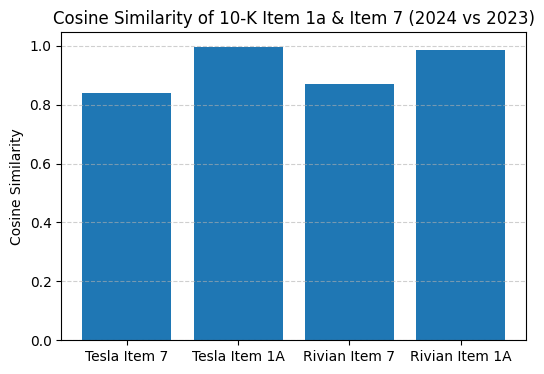

In [79]:
# Labels and values
sections = ['Tesla Item 7', 'Tesla Item 1A', 'Rivian Item 7', 'Rivian Item 1A']
scores = [tsla_item7_score, tsla_item1a_score, rivn_item7_score, rivn_item1a_score]

# Create bar chart
plt.figure(figsize=(6, 4))
plt.bar(sections, scores)
plt.title("Cosine Similarity of 10-K Item 1a & Item 7 (2024 vs 2023)")
plt.ylabel("Cosine Similarity")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## 10k Topic Modeling

In [80]:
def get_topics_from_text(text, num_keywords=10, stopword_list=None):
    if not text or len(text.split()) < 3:
        return ["(no meaningful topics found)"]

    if stopword_list is None:
        stopword_list = []

    vectorizer = TfidfVectorizer(
        stop_words=stopword_list,
        max_features=1000,
        token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b'
    )

    try:
        tfidf = vectorizer.fit_transform([text])
    except ValueError:
        return ["(no meaningful topics found)"]

    summed = tfidf.sum(axis=0).A1
    terms = vectorizer.get_feature_names_out()
    ranked_terms = sorted(zip(terms, summed), key=lambda x: x[1], reverse=True)
    return [term for term, _ in ranked_terms[:num_keywords]]

In [81]:
# Apply topic extraction to Item 1A
df_10k['item1a_topics'] = df_10k['item_1a'].apply(lambda x: get_topics_from_text(x, num_keywords=10))

# Apply topic extraction to Item 7
df_10k['item7_topics'] = df_10k['item_7'].apply(lambda x: get_topics_from_text(x, num_keywords=10))


/tmp/ipykernel_572/2058641361.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_10k['item1a_topics'] = df_10k['item_1a'].apply(lambda x: get_topics_from_text(x, num_keywords=10))


In [82]:
df_10k

,year,tikr,item_1a,item_7,item1a_topics,item7_topics
0,2023,TSLA,ITEM 1A RISK FACTORS You should carefully cons...,ITEM 7 MANAGEMENT’S DISCUSSION AND ANALYSIS OF...,"[and, our, to, of, or, the, we, in, may, be]","[and, the, of, to, our, in, we, as, for, on]"
1,2024,TSLA,ITEM 1A RISK FACTORS You should carefully cons...,ITEM 7 MANAGEMENT’S DISCUSSION AND ANALYSIS OF...,"[and, our, to, of, or, the, we, in, may, be]","[and, the, of, to, our, in, we, as, for, year]"
2,2023,RIVN,Item 1A Risk Factors Our business is subject t...,Item 7 Management’s Discussion and Analysis of...,"[and, to, our, of, the, or, in, we, may, be]","[and, the, of, our, to, in, we, for, as, on]"
3,2024,RIVN,Item 1A Risk Factors Our business is subject t...,Item 7 Management’s Discussion and Analysis of...,"[and, to, our, the, of, or, in, we, may, be]","[and, our, the, of, to, in, we, for, as, on]"


Prompt: code to extract the words in this link and store it as a list: https://www.mit.edu/~ecprice/wordlist.10000

In [83]:
import requests
import nltk
from nltk.corpus import stopwords

# Download stopwords from NLTK (if not already)
nltk.download('stopwords')

# Load MIT word list
url = "https://www.mit.edu/~ecprice/wordlist.10000"
response = requests.get(url)
if response.status_code == 200:
    word_list = response.text.splitlines()
    print(f"Loaded {len(word_list)} words.")
else:
    print("Failed to fetch the word list.")
    word_list = []

# Now safely combine all stopwords
nltk_stopwords = stopwords.words('english')
custom_stopwords = nltk_stopwords + word_list + [
    'company', 'management', 'business', 'report', 'vehicle',
    'billion', 'ended', 'january', 'february', 'march', 'april',
    'may', 'june', 'july', 'august', 'september', 'october', 'november',
    'december', 'year', 'revenue', 'costs', 'expenses', 'ability', 'us',
    'vehicles', 'could', 'results', 'certain', 'products', 'condition',
    'adversely', 'including', 'utomo', 'cannot', 'rivian', 'tesla', 'tive',
    'elon', 'musk', 'depreciation', 'amortization', 'anticipate', 'shortterm',
    'stockbased', 'incur', 'stockholders', 'ramping', 'ramp', 'theres', 'weve',
    'reeve', 'jonas', 'rivians', 'launching', 'mcdonough', 'scaringe', 'rauh', 'youre',
 'delaney',
 'goldman',
 'javier',
 'jv',
 'overyear',
 'sachs',
 'shreyas',
 'barclays'
]


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Loaded 10000 words.


In [84]:
# Apply topic extraction to Item 1A
df_10k['item1a_topics'] = df_10k['item_1a'].apply(lambda x: get_topics_from_text(x, num_keywords=10, stopword_list=custom_stopwords))

# Apply topic extraction to Item 7
df_10k['item7_topics'] = df_10k['item_7'].apply(lambda x: get_topics_from_text(x, num_keywords=10, stopword_list=custom_stopwords))

df_10k

,year,tikr,item_1a,item_7,item1a_topics,item7_topics
0,2023,TSLA,ITEM 1A RISK FACTORS You should carefully cons...,ITEM 7 MANAGEMENT’S DISCUSSION AND ANALYSIS OF...,"[harmed, indebtedness, jurisdictions, recalls,...","[deliveries, fsd, supercharging, liquidity, re..."
1,2024,TSLA,ITEM 1A RISK FACTORS You should carefully cons...,ITEM 7 MANAGEMENT’S DISCUSSION AND ANALYSIS OF...,"[harmed, indebtedness, jurisdictions, recalls,...","[deliveries, liquidity, supercharging, fsd, me..."
2,2023,RIVN,Item 1A Risk Factors Our business is subject t...,Item 7 Management’s Discussion and Analysis of...,"[materially, evs, thirdparty, opensource, juri...","[deliveries, remarketing, lcnrv, accrued, writ..."
3,2024,RIVN,Item 1A Risk Factors Our business is subject t...,Item 7 Management’s Discussion and Analysis of...,"[materially, evs, thirdparty, opensource, nega...","[deliveries, abl, issuance, liquidity, nrv, wr..."


In [85]:
def compare_topics(df, tikr, item_col):

    # Filter rows for that company and sort by year
    company_df = df[df['tikr'] == tikr].sort_values('year')

    topics_2023 = set(company_df[company_df['year'] == 2023][item_col].values[0])
    topics_2024 = set(company_df[company_df['year'] == 2024][item_col].values[0])

    added = topics_2024 - topics_2023
    removed = topics_2023 - topics_2024
    unchanged = topics_2023 & topics_2024

    return {
        'company': tikr,
        'section': item_col,
        'added_topics': list(added),
        'removed_topics': list(removed),
        'unchanged_topics': list(unchanged)
    }

topics = pd.DataFrame([
    compare_topics(df_10k, 'TSLA', 'item1a_topics'),
    compare_topics(df_10k, 'TSLA', 'item7_topics'),
    compare_topics(df_10k, 'RIVN', 'item1a_topics'),
    compare_topics(df_10k, 'RIVN', 'item7_topics')
])


In [86]:
topics

,company,section,added_topics,removed_topics,unchanged_topics
0,TSLA,item1a_topics,[residual],[impacted],"[gigafactory, jurisdictions, profitability, re..."
1,TSLA,item7_topics,"[gigafactory, megapack]","[servicing, autonomy]","[deliveries, salestype, fsd, realizable, cyber..."
2,RIVN,item1a_topics,[],[],"[restated, jurisdictions, evolving, materially..."
3,RIVN,item7_topics,"[abl, issuance, ecosystem, nrv, contingencies,...","[lcnrv, remarketing, comprised, msp, yearovery...","[deliveries, writedowns, borrowings]"


In [87]:
print(f"topics for Tesla's Item 1A: {topics['unchanged_topics'].loc[0]}")
print('\n')
print(f"topics for Tesla's Item 7: {topics['unchanged_topics'].loc[1]}")
print('\n')
print(f"topics for Rivian's Item 1A: {topics['unchanged_topics'].loc[2]}")
print('\n')
print(f"topics for Rivian's Item 7: {topics['unchanged_topics'].loc[3]}")

topics for Tesla's Item 1A: ['gigafactory', 'jurisdictions', 'profitability', 'recalls', 'autopilot', 'lithiumion', 'servicing', 'harmed', 'indebtedness']


topics for Tesla's Item 7: ['deliveries', 'salestype', 'fsd', 'realizable', 'cybertruck', 'factories', 'supercharging', 'liquidity']


topics for Rivian's Item 1A: ['restated', 'jurisdictions', 'evolving', 'materially', 'esg', 'evs', 'opensource', 'thirdparty', 'negatively', 'costly']


topics for Rivian's Item 7: ['deliveries', 'writedowns', 'borrowings']


Applying topic modeling to the earnings transcript

In [88]:
df_earnings

,tikr,earnings_call,management_discussion,q&a
0,TSLA,CORPORATE PARTICIPANTS Travis Axelrod Head Inv...,Travis Axelrod Head Investor Relations Tesla I...,Travis Axelrod Head Investor Relations Tesla I...
1,RIVN,CORPORATE PARTICIPANTS Timothy Bei Vice Presid...,Operator Good day Thank you for standing by We...,Operator Thank you Our first question will com...


In [89]:
# Apply topic extraction to earnings call
df_earnings['earnings_call_topics'] = df_earnings['earnings_call'].apply(lambda x: get_topics_from_text(x, num_keywords=10, stopword_list=custom_stopwords))

/tmp/ipykernel_572/279711106.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_earnings['earnings_call_topics'] = df_earnings['earnings_call'].apply(lambda x: get_topics_from_text(x, num_keywords=10, stopword_list=custom_stopwords))


In [90]:
print(f"topics in Tesla's Earnings Call: {df_earnings['earnings_call_topics'].loc[0]}")
print('\n')
print(f"topics in Rivian's Earnings Call: {df_earnings['earnings_call_topics'].loc[1]}")

topics in Tesla's Earnings Call: ['technoking', 'optimus', 'axelrod', 'fsd', 'unsupervised', 'vaibhav', 'taneja', 'autonomy', 'lidar', 'autonomous']


topics in Rivian's Earnings Call: ['autonomy', 'cogs', 'capex', 'ebitda', 'gaap', 'genuity', 'gianarikas', 'gpus', 'incremental', 'learnings']
